### Risk Adjusted Lending

In [1]:

# STEP 1: IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import matplotlib.patches as patches

In [2]:

# STEP 2: MOUNT GOOGLE DRIVE

from google.colab import drive

# Mount Google Drive to access the workspace directory
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# STEP 3: LOAD THE DATASET AND DISPLAY INITIAL SHAPE AND HEAD

# Define the file path
file_path = '/content/drive/My Drive/RCEL 506/SBA Dataset.csv'

# Load the dataset with the specified parameters
df = pd.read_csv(file_path, encoding='latin1', low_memory=False)

# Print the shape of the dataset
print(f"Dataset Shape: {df.shape}")

# Display the first 5 rows
print("\nFirst 5 Rows:")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
df.head(5)


Dataset Shape: (545751, 39)

First 5 Rows:


,AsOfDate,Program,BorrName,BorrStreet,BorrCity,BorrState,BorrZip,BankName,BankFDICNumber,BankNCUANumber,BankStreet,BankCity,BankState,BankZip,GrossApproval,SBAGuaranteedApproval,ApprovalDate,ApprovalFiscalYear,FirstDisbursementDate,DeliveryMethod,subpgmdesc,InitialInterestRate,TermInMonths,NaicsCode,NaicsDescription,FranchiseCode,FranchiseName,ProjectCounty,ProjectState,SBADistrictOffice,CongressionalDistrict,BusinessType,BusinessAge,LoanStatus,PaidInFullDate,ChargeOffDate,GrossChargeOffAmount,RevolverStatus,JobsSupported
0,20221231,7A,RIVERLAND LASER LLC,703 ST CROIX STREET,RIVER FALLS,WI,54022,First National Community Bank,5357.0,NaN,109 E 2nd St,NEW RICHMOND,WI,54017,491000,441900.0,10/01/2009,2010,10/01/2009,OTH 7A,Guaranty,6.00,120,332812.0,"Metal Coating, Engraving (except Jewelry and S...",NaN,NaN,PIERCE,WI,WISCONSIN DISTRICT OFFICE,7.0,CORPORATION,NaN,PIF,08/31/2016,NaN,0,0,11
1,20221231,7A,MARTINEZ AND MARTINEZ INC.,2430 DALY AVE,LOS ANGELES,CA,90031,Gain FCU,NaN,3943.0,1800 W Magnolia Blvd,BURBANK,CA,91506,35000,31500.0,10/01/2009,2010,04/01/2011,OTH 7A,Guaranty,6.50,60,541213.0,Tax Preparation Services,NaN,NaN,LOS ANGELES,CA,LOS ANGELES DISTRICT OFFICE,28.0,CORPORATION,NaN,PIF,04/30/2016,NaN,0,1,9
2,20221231,7A,Erez & Koby Genesis Investment,"10999 Reed Hartman Hwy, SUit",CINCINNATI,OH,45242,"JPMorgan Chase Bank, National Association",628.0,NaN,1111 Polaris Pkwy,COLUMBUS,OH,43240,100500,50250.0,10/01/2009,2010,10/01/2009,SBA EXPRES,FA$TRK (Small Loan Express),4.51,54,722110.0,Full-Service Restaurants,NaN,NaN,HAMILTON,OH,COLUMBUS DISTRICT OFFICE,1.0,CORPORATION,NaN,PIF,05/31/2012,NaN,0,0,20
3,20221231,7A,Square Burger LLC,115 Kentucky Street,McKinney,TX,75069,American Bank of Commerce,18609.0,NaN,530 E Hwy 62/82,WOLFFORTH,TX,79382,288000,259200.0,10/01/2009,2010,10/01/2009,PLP,Guaranty,6.00,120,722110.0,Full-Service Restaurants,NaN,NaN,COLLIN,TX,DALLAS / FT WORTH DISTRICT OFFICE,3.0,CORPORATION,NaN,PIF,07/31/2014,NaN,0,0,18
4,20221231,7A,HIT FITNESS LLC,614 A SOUTH MAIN STREET,MAULDIN,SC,29662,Truist Bank,9846.0,NaN,214 N Tryon St,CHARLOTTE,NC,28202,37000,18500.0,10/01/2009,2010,10/01/2009,SBA EXPRES,FA$TRK (Small Loan Express),7.50,60,812199.0,Other Personal Care Services,NaN,NaN,GREENVILLE,SC,SOUTH CAROLINA DISTRICT OFFICE,4.0,CORPORATION,NaN,PIF,09/30/2013,NaN,0,0,6


In [4]:
# STEP 4: CHECK DATA TYPES AND ANALYSIS OF MISSING VALUES

# Print all column data types using df.dtypes
print("Column Data Types")
print(df.dtypes)
print("\n" + "="*50 + "\n")

# Create a missing values summary table
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent
})

# Sort by Missing percentage in a descending
missing_summary = missing_summary.sort_values(by='Missing %', ascending=False)

# Filter and print only columns that have at least 1 missing value
missing_filtered = missing_summary[missing_summary['Missing Count'] > 0]

print("Columns with Missing Values")
print(missing_filtered)



Column Data Types
AsOfDate                   int64
Program                   object
BorrName                  object
BorrStreet                object
BorrCity                  object
BorrState                 object
BorrZip                    int64
BankName                  object
BankFDICNumber           float64
BankNCUANumber           float64
BankStreet                object
BankCity                  object
BankState                 object
BankZip                   object
GrossApproval              int64
SBAGuaranteedApproval    float64
ApprovalDate              object
ApprovalFiscalYear         int64
FirstDisbursementDate     object
DeliveryMethod            object
subpgmdesc                object
InitialInterestRate      float64
TermInMonths               int64
NaicsCode                float64
NaicsDescription          object
FranchiseCode             object
FranchiseName             object
ProjectCounty             object
ProjectState              object
SBADistrictOffice        

## Target Variable Cleaning

`LoanStatus` contains 5 values but we only care about 2 resolved outcomes:
- Keep `PIF` (Paid in Full) which is converted to `0`
- Keep `CHGOFF` (Charged Off / Defaulted) which converted to `1`
- Drop `CANCLD`, `EXEMPT`, `COMMIT` these loans never had a real outcome

The new `Default` column (0 or 1) is what the model will use for prediction.

>  `ChargeOffDate`, `PaidInFullDate`, and `GrossChargeOffAmount` are dropped
> to avoid data leakage, they only exist after a loan already defaulted or paid in full.

In [5]:
# STEP 5: CLEAN TARGET VARIABLE AND CALCULATE BASELINE METRICS

# Keep only rows where LoanStatus is 'PIF' or 'CHGOFF'
df = df[df['LoanStatus'].isin(['PIF', 'CHGOFF'])].copy()

# Create the  target variable 'Default' (1 for CHGOFF, 0 for PIF)
df['Default'] = np.where(df['LoanStatus'] == 'CHGOFF', 1, 0)

# Print the value counts of the Default column
print("Default Count':")
print(df['Default'].value_counts())

# Calculate and print the default rate as a percentage
default_rate = df['Default'].mean() * 100
print(f"\nDefault Rate: {default_rate:.2f}%")

# Print the new shape of the dataframe
print(f"\nNew Dataset Shape: {df.shape}")



Default Count':
Default
0    319229
1     27916
Name: count, dtype: int64

Default Rate: 8.04%

New Dataset Shape: (347145, 40)


## Dropped Columns
- **Too specific/identifiers:** `BorrName`, `BorrStreet`, `BorrCity`, `BorrZip`, `ProjectCounty`
- **Bank details:** `BankName`, `BankFDICNumber`, `BankNCUANumber`, `BankStreet/City/State/Zip`
- **91%+ missing:** `FranchiseCode`, `FranchiseName`
- **79.5% missing:** `BusinessAge`
- **Redundant:**  `ApprovalDate`
- **Administrative:** `SBADistrictOffice`, `CongressionalDistrict`, `AsOfDate`, `Program`
- **Data leakage:** `PaidInFullDate`, `ChargeOffDate`, `GrossChargeOffAmount`

In [6]:
# STEP 6: DROP SPECIFIED COLUMNS BY OPERATIONAL GROUPS

# Columns list structured precisely by structural groupings
columns_to_drop = [
    # Borrower identifiers: not predictive
    'BorrName', 'BorrStreet', 'BorrCity', 'BorrZip',

    # Bank details: not relevant to default risk
    'BankName', 'BankFDICNumber', 'BankNCUANumber',
    'BankStreet', 'BankCity', 'BankState', 'BankZip',

    # Dates: ApprovalFiscalYear already captures the year
    'ApprovalDate', 'FirstDisbursementDate',

    # 91%+ missing: unusable
    'FranchiseCode', 'FranchiseName',

    # 79.5% missing: unusable
    'BusinessAge',

    # Too specific: using ProjectState instead
    'ProjectCounty',

    # Administrative: not predictive
    'SBADistrictOffice', 'CongressionalDistrict',
    'AsOfDate', 'Program',

    # Data leakage: outcome columns
    'LoanStatus', 'PaidInFullDate',
    'ChargeOffDate', 'GrossChargeOffAmount'
]

# Drop columns
df = df.drop(columns=columns_to_drop)

# Print the remaining column list
print("Remaining Columns:")
print(df.columns.tolist())
print("\n" + "="*50 + "\n")

# Print the new dataset shape
print(f"New Dataset Shape: {df.shape}")

Remaining Columns:
['BorrState', 'GrossApproval', 'SBAGuaranteedApproval', 'ApprovalFiscalYear', 'DeliveryMethod', 'subpgmdesc', 'InitialInterestRate', 'TermInMonths', 'NaicsCode', 'NaicsDescription', 'ProjectState', 'BusinessType', 'RevolverStatus', 'JobsSupported', 'Default']


New Dataset Shape: (347145, 15)


In [6]:
# STEP 7: POST-CLEANING MISSING VALUE ANALYSIS

# Create a missing values summary table for the current dataframe state
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent
})

# Sort by Missing percentage in descending order
missing_summary = missing_summary.sort_values(by='Missing %', ascending=False)

# Filter and print only columns that have at least 1 missing value
missing_filtered = missing_summary[missing_summary['Missing Count'] > 0]

print("Remaining Columns with Missing Values:")
print(missing_filtered)
print("\n" + "="*50 + "\n")

# Calculate and print the total number of unique rows affected by any missing value
rows_with_nan = df.isnull().any(axis=1).sum()
print(f"Total rows affected by at least one missing value: {rows_with_nan}")


Remaining Columns with Missing Values:
                       Missing Count  Missing %
BankNCUANumber                335432  96.625906
FranchiseName                 319933  92.161201
FranchiseCode                 319900  92.151695
ChargeOffDate                 319230  91.958692
BusinessAge                   310335  89.396362
PaidInFullDate                 27916   8.041596
BankFDICNumber                 24367   7.019257
FirstDisbursementDate           1090   0.313990
NaicsDescription                 234   0.067407
CongressionalDistrict             23   0.006625
BorrName                          13   0.003745
NaicsCode                          7   0.002016
BusinessType                       3   0.000864
BankState                          1   0.000288
BankStreet                         1   0.000288
BankZip                            1   0.000288
ProjectCounty                      1   0.000288
BankCity                           1   0.000288


Total rows affected by at least one missing val

In [7]:
# STEP 8: ADJUSTMENTS OF MISSING ENTIRES

# Fill missing NaicsDescription with 'Unknown'
df['NaicsDescription'] = df['NaicsDescription'].fillna('Unknown')

# Drop rows where NaicsCode is missing
df = df.dropna(subset=['NaicsCode'])

# Drop rows where BusinessType is missing
df = df.dropna(subset=['BusinessType'])

# Print the new shape
print(f"New Dataset Shape after dropping: {df.shape}")


# Confirm 0 missing values remain
remaining_missing = df.isnull().sum().sum()
print(f"Total missing values remaining in the entire DataFrame: {remaining_missing}")

New Dataset Shape after dropping: (347135, 40)
Total missing values remaining in the entire DataFrame: 1658196


### Data Visualization
## Target Variable Distribution

The dataset contains 347,135 loans after cleaning. Of those:
- **92%** (319,221) were successfully repaid (Paid in Full)
- **8%** (27,914) ended in default (Charged Off)

This is a class imbalance problem the model will see far more
repaid loans than defaults during training. Raw accuracy is therefore a poor metric here: a model that predicts 'no default' for every loan would score 92% accuracy while being completely useless. F1 Score and PR-AUC are used instead.

Target Value Counts:
Default
0    319221
1     27914
Name: count, dtype: int64

Target Percentages:
Default
0    91.958748
1     8.041252
Name: proportion, dtype: float64




/tmp/ipykernel_27577/2840069838.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Paid in Full (0)', 'Defaulted (1)'])


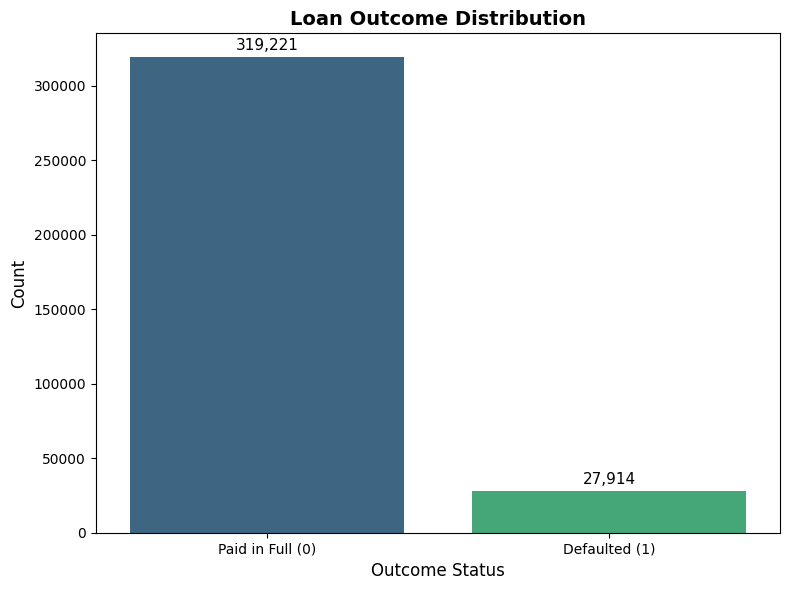

Total loans: 347,135
Paid in Full count: 319,221 (91.96%)
Defaulted count: 27,914 (8.04%)


In [8]:
# STEP 9: TARGET VARIABLE DISTRIBUTION VISUALIZATION


# 1. Print the value counts and percentages of the Default column
counts = df['Default'].value_counts()
percentages = df['Default'].value_counts(normalize=True) * 100

print("Target Value Counts:")
print(counts)
print("\nTarget Percentages:")
print(percentages)
print("\n" + "="*50 + "\n")

# 2. Create a bar chart
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Default', hue='Default', data=df, palette='viridis', legend=False)

# Set title and axis designations
plt.title('Loan Outcome Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Outcome Status', fontsize=12)
ax.set_xticklabels(['Paid in Full (0)', 'Defaulted (1)'])
plt.ylabel('Count', fontsize=12)

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black',
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# 3. Print the summary
total_loans = len(df)
pif_count = counts[0]
pif_pct = percentages[0]
def_count = counts[1]
def_pct = percentages[1]

print(f"Total loans: {total_loans:,}")
print(f"Paid in Full count: {pif_count:,} ({pif_pct:.2f}%)")
print(f"Defaulted count: {def_count:,} ({def_pct:.2f}%)")


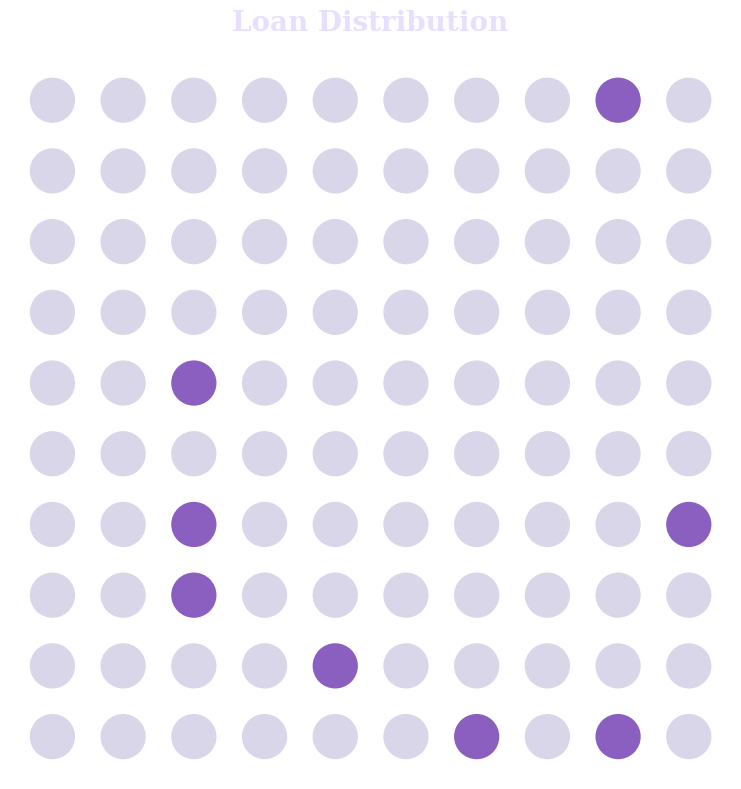

In [9]:
BASE_COLOR = '#D9D6EA'      # "paid back" dots
HIGHLIGHT_COLOR = '#8B5FBF' # "defaulted dots
TITLE_COLOR = '#241C4E'


rows, cols = 10, 10
dot_radius = 0.32
spacing = 1.0


default_rate_pct = df['Default'].mean() * 100
n_highlighted = round(default_rate_pct)

rng = np.random.default_rng(seed=42)
all_cells = [(r, c) for r in range(rows) for c in range(cols)]
highlighted_idx = rng.choice(len(all_cells), size=n_highlighted, replace=False)
highlighted = {all_cells[i] for i in highlighted_idx}

fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_alpha(0)
ax.set_facecolor('none')

for r in range(rows):
    for c in range(cols):
        color = HIGHLIGHT_COLOR if (r, c) in highlighted else BASE_COLOR
        circle = patches.Circle(
            (c * spacing, (rows - 1 - r) * spacing),
            radius=dot_radius,
            facecolor=color,
            edgecolor='none'
        )
        ax.add_patch(circle)

ax.set_xlim(-0.6, cols * spacing - 0.4)
ax.set_ylim(-0.6, rows * spacing - 0.4)
ax.set_aspect('equal')
ax.axis('off')

# Title
plt.title('Loan Distribution',
           fontsize=20, fontweight='bold', color='#E8DFFF',
           loc='center', pad=20, fontfamily='serif')

plt.tight_layout()
plt.savefig('dot_grid.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()


## Default Rate by State

Default rates vary significantly by state, confirming that
location is a meaningful feature for the model.States and territories with fewer than 100 loans are excluded from the ranking below, since a small handful of loans can produce a misleading default rate

- **Highest:** FL (12.3%), SC (11.1%), TX (11.0%), AL (10.9%),
  NJ (10.4%).
- **Lowest:** ND (3.5%), MT (4.1%), ID (4.6%)
- **Excluded:** MP, VI, MH, and FM. MP have less than 100 loans

/tmp/ipykernel_27577/530273590.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=state_default_rates_sorted.index, y=state_default_rates_sorted.values, palette='Blues_r')


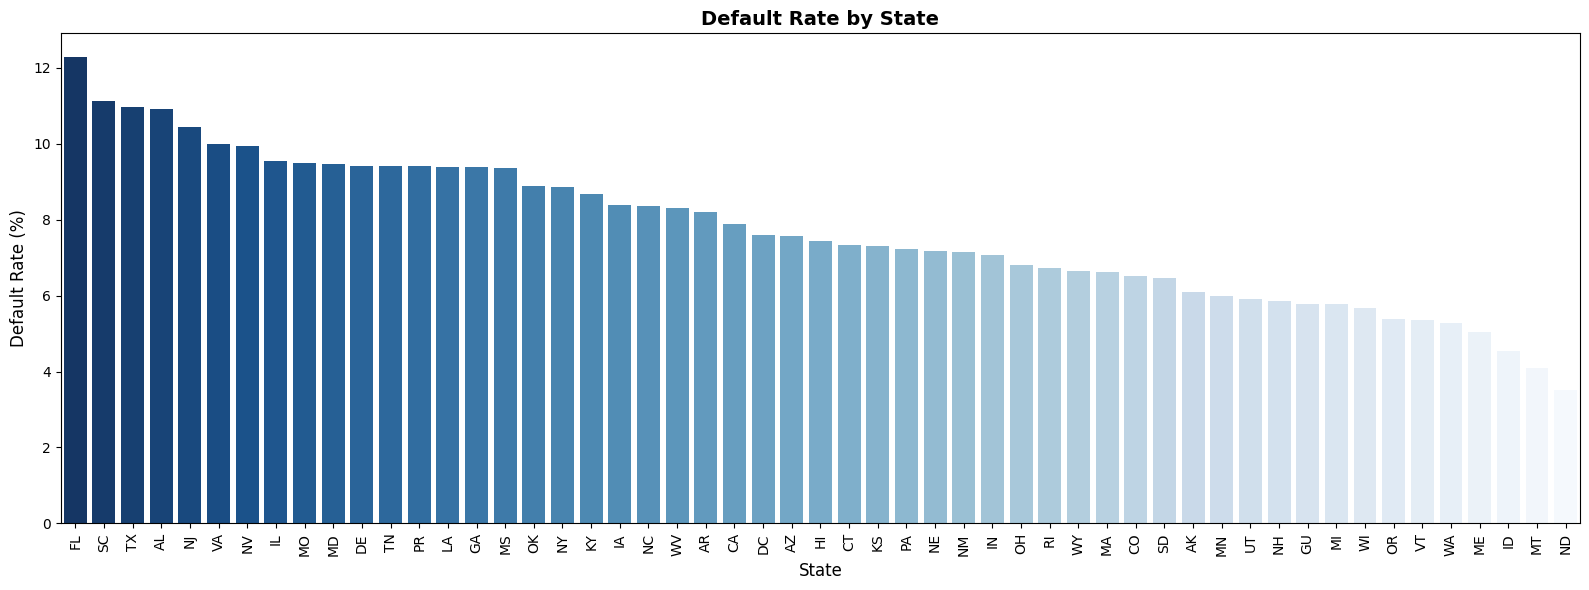

Top 5 Highest Default States:
BorrState
FL    12.287531
SC    11.124897
TX    10.966585
AL    10.907577
NJ    10.429373
Name: Default_Rate, dtype: float64

Top 5 Lowest Default States:
BorrState
WA    5.277101
ME    5.047319
ID    4.553073
MT    4.095720
ND    3.511339
Name: Default_Rate, dtype: float64

4 states/territories excluded (fewer than 100 loans):
           Default_Rate  Loan_Count
BorrState                          
MP            50.000000           4
VI            10.714286          56
MH             0.000000           1
FM             0.000000           2


In [10]:
# STEP 10: DEFAULT RATE BY STATE (min 100 loans to avoid small-sample noise)
state_stats = df.groupby('BorrState')['Default'].agg(['mean', 'count'])
state_stats['Default_Rate'] = state_stats['mean'] * 100
state_stats = state_stats.rename(columns={'count': 'Loan_Count'})

# Filter to states with at least 100 loans before ranking
state_stats_filtered = state_stats[state_stats['Loan_Count'] >= 100]
state_default_rates_sorted = state_stats_filtered['Default_Rate'].sort_values(ascending=False)

plt.figure(figsize=(16, 6))
ax = sns.barplot(x=state_default_rates_sorted.index, y=state_default_rates_sorted.values, palette='Blues_r')

plt.title('Default Rate by State', fontsize=14, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

print("Top 5 Highest Default States:")
print(state_default_rates_sorted.head(5))
print("\nTop 5 Lowest Default States:")
print(state_default_rates_sorted.tail(5))

# Excluded low-sample states
excluded = state_stats[state_stats['Loan_Count'] < 100].sort_values('Default_Rate', ascending=False)
print(f"\n{len(excluded)} states/territories excluded (fewer than 100 loans):")
print(excluded[['Default_Rate', 'Loan_Count']])

## Loan Amount Distribution

Both distributions are right-skewed: most SBA loans are under 500,000 dollars
with a smaller number of larger loans extending up to 5 million dollars

Defaulted loans had a lower average approval amount (204,527) than
loans paid in full (340,227): a 40% difference. This runs counter to
the intuitive assumption that larger loans carry more risk. Instead, it
suggests the opposite: businesses borrowing smaller amounts may be
smaller or newer operations with less financial cushion, making them
more vulnerable to default than larger, more established borrowers.

This makes `GrossApproval` a useful predictive feature.

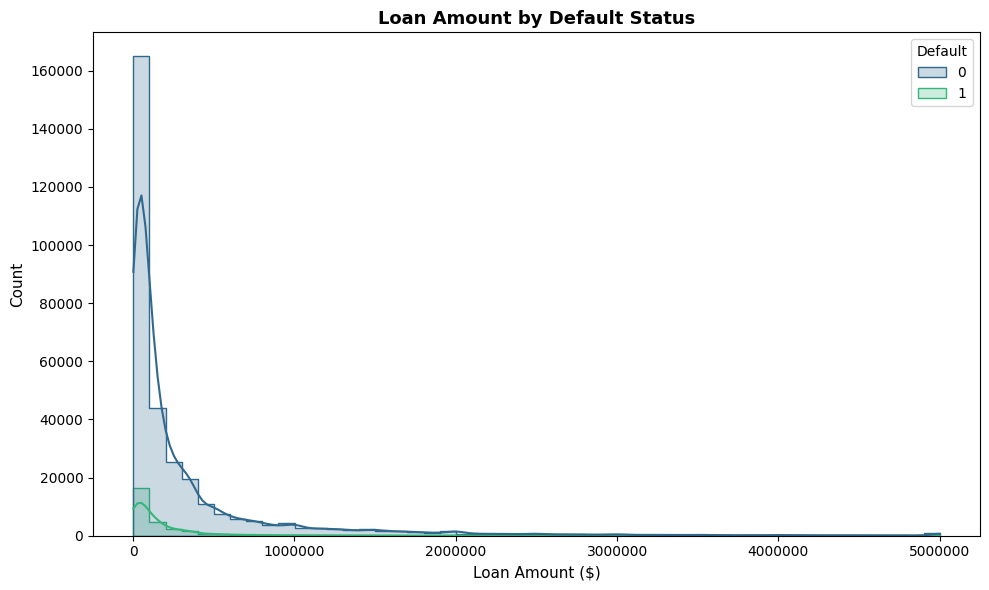

AVERAGE LOAN AMOUNT BY GROUP:
Paid in Full (0): $340,226.88
Defaulted (1): $204,526.69


In [11]:

# STEP 11: LOAN AMOUNT BY DEFAULT STATUS
plt.figure(figsize=(10, 6))

# Create histogram of GrossApproval split by Default status
sns.histplot(data=df, x='GrossApproval', hue='Default', bins=50, kde=True,
             palette='viridis', multiple='layer', element='step')

plt.title('Loan Amount by Default Status', fontsize=13, fontweight='bold')
plt.xlabel('Loan Amount ($)', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

# Print average loan amount for each group
avg_loan_by_group = df.groupby('Default')['GrossApproval'].mean()
print("AVERAGE LOAN AMOUNT BY GROUP:")
print(f"Paid in Full (0): ${avg_loan_by_group[0]:,.2f}")
print(f"Defaulted (1): ${avg_loan_by_group[1]:,.2f}")

## Default Rate by Business Type

Individual borrowers have the highest default rate at 9.1%, compared to Corporations (8.0%) and Partnerships (4.7%).

Corporations make up the vast majority of loans (301,254) while Partnerships are the smallest group (6,149), so the model will
learn mostly from corporate borrowing patterns.

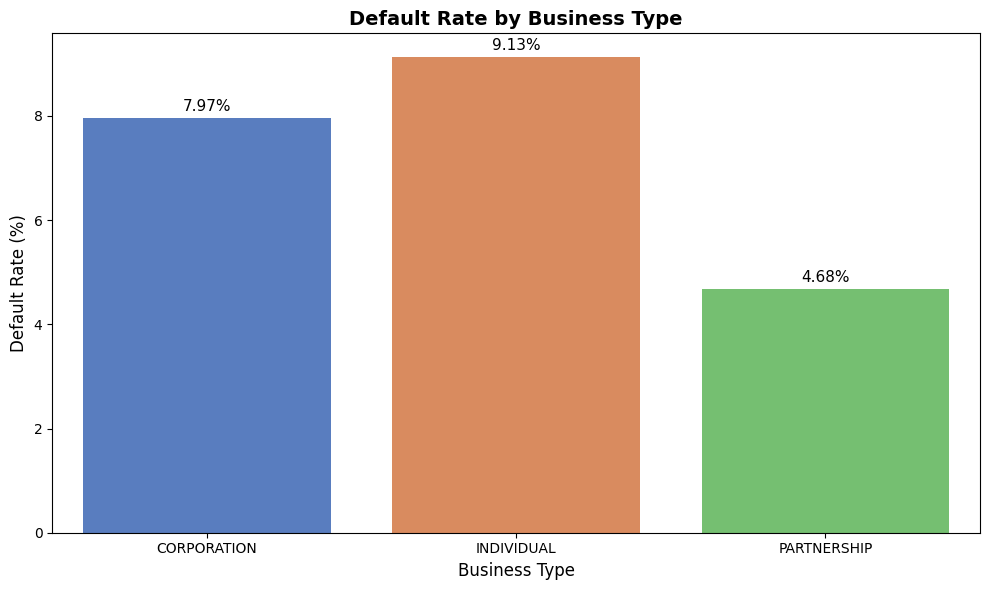

BUSINESS TYPE SUMMARY TABLE:
             Default Rate Total Loans
BusinessType                         
CORPORATION         7.97%     301,254
INDIVIDUAL          9.13%      39,732
PARTNERSHIP         4.68%       6,149


In [12]:
# STEP 12: DEFAULT RATE BY BUSINESS TYPE ANALYSIS AND VISUALIZATION

# Calculate default rate per BusinessType
business_default_rates = df.groupby('BusinessType')['Default'].mean() * 100

# Create a bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=business_default_rates.index, y=business_default_rates.values,
                  hue=business_default_rates.index, palette='muted', legend=False)
# Set chart parameters
plt.title('Default Rate by Business Type', fontsize=14, fontweight='bold')
plt.xlabel('Business Type', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)

# Add percentage labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black',
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# 3. Print a summary table for each BusinessType showing Default Rate and Total Loans
total_loans_by_type = df.groupby('BusinessType').size()

summary_table = pd.DataFrame({
    'Default Rate': business_default_rates,
    'Total Loans': total_loans_by_type
})


print("BUSINESS TYPE SUMMARY TABLE:")
print(summary_table.to_string(formatters={'Default Rate': '{:,.2f}%'.format, 'Total Loans': '{:,}'.format}))


## Default Rate by Revolving Credit Status

Non-revolving (8.0%) and revolving (8.1%) loans have almostidentical default rates a difference of only 0.1%.

This suggests `RevolverStatus` alone is not a strong predictor of default. However, it may still interact with other features in ways the model can learn from, so it will be kept and let the model determine its importance during training.

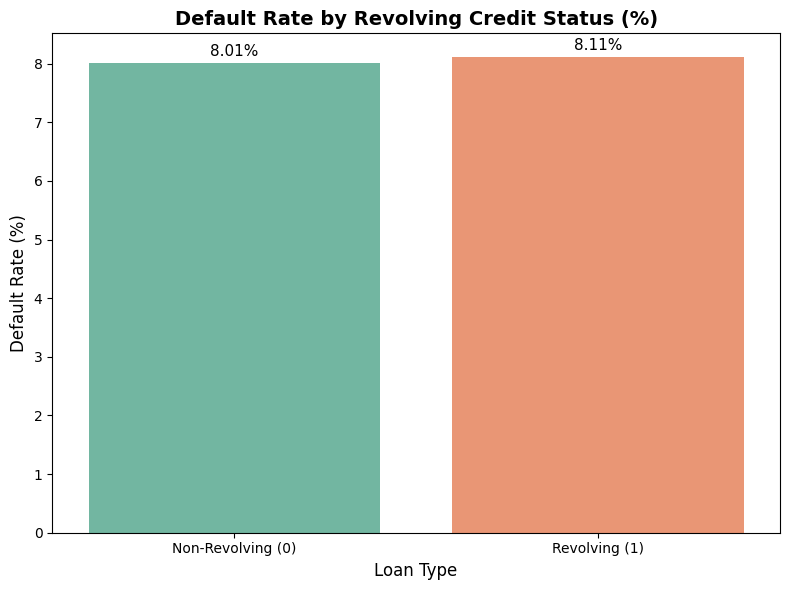

REVOLVING CREDIT STATUS SUMMARY TABLE:
               Default Rate Total Loans
RevolverStatus                         
0                     8.01%     231,127
1                     8.11%     116,008


In [13]:
# STEP 13: DEFAULT RATE BY REVOLVING CREDIT STATUS ANALYSIS & VISUALIZATION


# Calculate default rate per RevolverStatus
revolver_default_rates = df.groupby('RevolverStatus')['Default'].mean() * 100

# Create a bar chart
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=revolver_default_rates.index, y=revolver_default_rates.values,
                  hue=revolver_default_rates.index, palette='Set2', legend=False)

# Set chart parameters
plt.title('Default Rate by Revolving Credit Status (%)', fontsize=14, fontweight='bold')
plt.xlabel('Loan Type', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Non-Revolving (0)', 'Revolving (1)'])
plt.ylabel('Default Rate (%)', fontsize=12)

# Add percentage labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black',
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# Print a summary table for each RevolverStatus showing Default Rate and Total Loans
total_loans_by_status = df.groupby('RevolverStatus').size()

summary_table = pd.DataFrame({
    'Default Rate': revolver_default_rates,
    'Total Loans': total_loans_by_status
})

print("REVOLVING CREDIT STATUS SUMMARY TABLE:")
print(summary_table.to_string(formatters={'Default Rate': '{:,.2f}%'.format, 'Total Loans': '{:,}'.format}))


## Default Rate by Approval Fiscal Year

Default rates started relatively high in 2010 (9.72%), likely still
reflecting the aftermath of the 2008 financial crisis. Rates then dropped
to their lowest point in 2013 (6.51%) as the economy recovered. From 2013
onward, default rates climbed steadily, peaking in 2018 (10.65%) before
declining slightly in 2019 (8.56%).

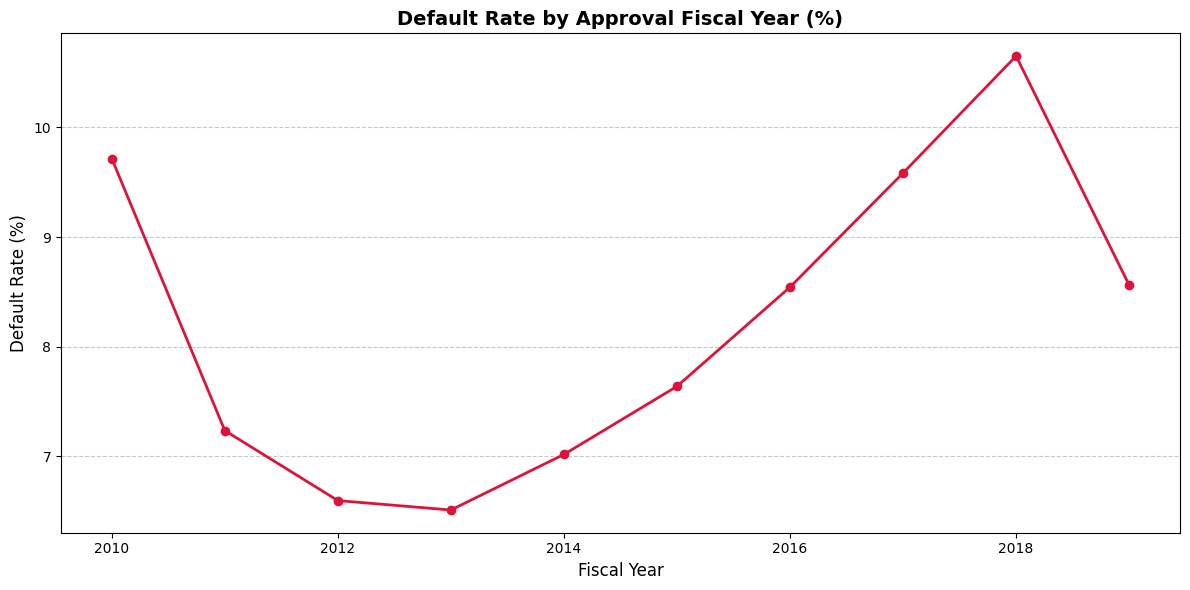

DEFAULT RATE BY FISCAL YEAR SUMMARY:
Fiscal Year 2010: 9.72%
Fiscal Year 2011: 7.24%
Fiscal Year 2012: 6.60%
Fiscal Year 2013: 6.51%
Fiscal Year 2014: 7.02%
Fiscal Year 2015: 7.64%
Fiscal Year 2016: 8.54%
Fiscal Year 2017: 9.58%
Fiscal Year 2018: 10.65%
Fiscal Year 2019: 8.56%


In [14]:
# STEP 14: DEFAULT RATE BY FISCAL YEAR TREND ANALYSIS

# Calculate default rate per ApprovalFiscalYear
fiscal_default_rates = df.groupby('ApprovalFiscalYear')['Default'].mean() * 100

# Create a line chart
plt.figure(figsize=(12, 6))
plt.plot(fiscal_default_rates.index, fiscal_default_rates.values,
          marker='o', color='crimson', linewidth=2)
# Set chart parameters
plt.title('Default Rate by Approval Fiscal Year (%)', fontsize=14, fontweight='bold')
plt.xlabel('Fiscal Year', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)

# Add grid lines on y-axis only
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 3. Print the default rate for each year
print("DEFAULT RATE BY FISCAL YEAR SUMMARY:")
for year, rate in fiscal_default_rates.items():
    print(f"Fiscal Year {year}: {rate:.2f}%")


## Top 10 Industries by Default Rate

Electronics and repair businesses have the highest default
rates in our dataset:

- Computer & Office Machine Repair (26.4%): highest
  of all industries
- Electronics Wholesalers, Stores & E-commerce
  (19–21%): retail electronics struggled during 2010-2019
- Limousine Service (18.2%): dependent on
  non-essential spending
- Performing Arts Promoters (16.4%) and Tutoring
  (16.3%): seasonal and unpredictable revenue


In [15]:
#PREPARE TOP 10 INDUSTRIES BY DEFAULT RATE (min 100 loans to avoid small-sample noise)
industry_stats = df.groupby('NaicsDescription')['Default'].agg(['mean', 'count'])
industry_stats['Default_Rate'] = industry_stats['mean'] * 100
industry_stats = industry_stats.rename(columns={'count': 'Loan_Count'})

# Filter to industries with at least 100 loans, then take top 10 by default rate
top_10_merged = industry_stats[industry_stats['Loan_Count'] >= 100].sort_values(
    'Default_Rate', ascending=False
).head(10).reset_index()

# Wrap long industry names so they fit on the y-axis (textwrap imported in Step 1)
top_10_merged['NaicsDescription_Wrapped'] = top_10_merged['NaicsDescription'].apply(
    lambda x: textwrap.fill(x, width=35)
)

print("Top 10 Industries by Default Rate (min. 100 loans):")
print(top_10_merged[['NaicsDescription', 'Default_Rate', 'Loan_Count']].to_string(index=False))

Top 10 Industries by Default Rate (min. 100 loans):
                                                      NaicsDescription  Default_Rate  Loan_Count
                    Computer and Office Machine Repair and Maintenance     26.397516         322
Electrical and Electronic Appliance, Television, and Radio Set Merchan     21.000000         200
                                                    Electronics Stores     20.704846         454
                             Electronic Shopping and Mail-Order Houses     19.364162         346
                                      Appliance Repair and Maintenance     18.357488         207
                                                     Limousine Service     18.200000         500
       Other Electronic and Precision Equipment Repair and Maintenance     17.500000         280
Promoters of Performing Arts, Sports, and Similar Events without Facil     16.400000         250
                                         Exam Preparation and Tutoring     

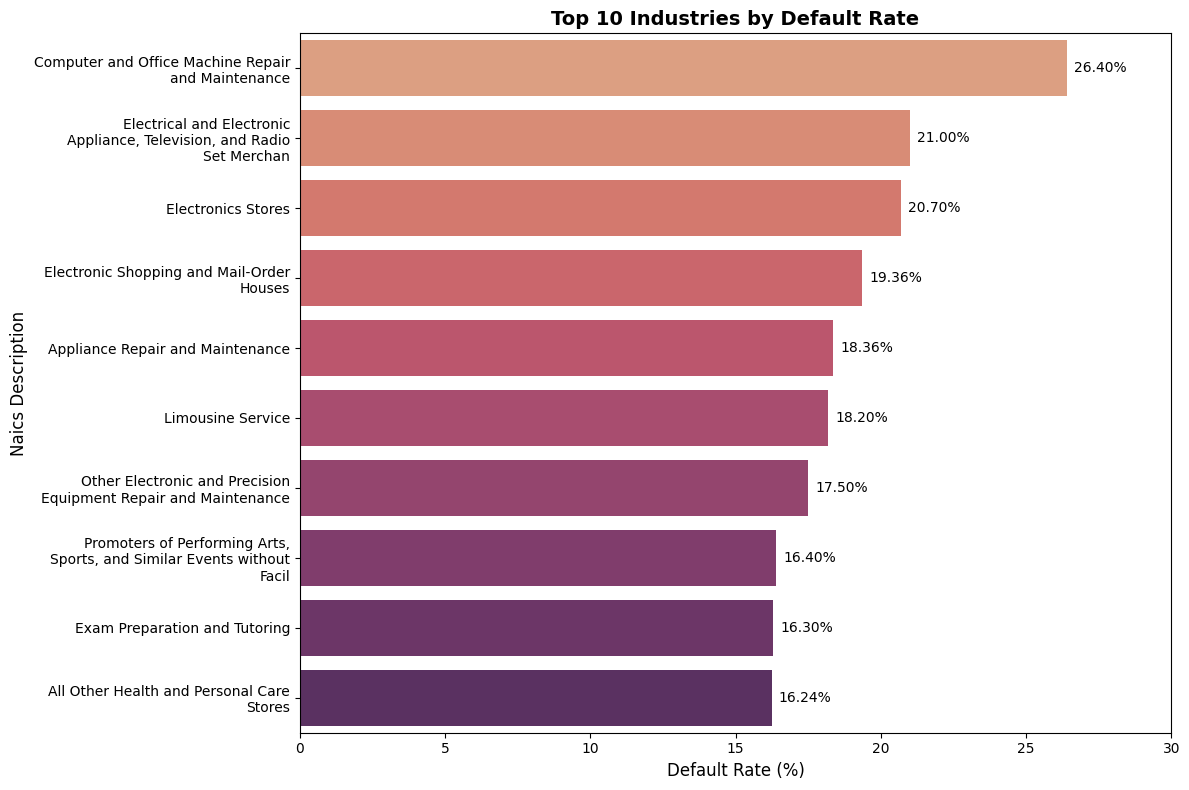

In [16]:
# STEP 15: TOP 10 INDUSTRIES BY DEFAULT RATE
plt.figure(figsize=(12, 8)) # setting figure size here
ax = sns.barplot(x='Default_Rate', y='NaicsDescription_Wrapped', data=top_10_merged,
                  hue='NaicsDescription_Wrapped', palette='flare', legend=False)
#Create bar chart
plt.title('Top 10 Industries by Default Rate', fontsize=14, fontweight='bold')
# Set chart parameters
plt.xlabel('Default Rate (%)', fontsize=12)
plt.ylabel('Naics Description', fontsize=12)
plt.xlim(0, 30)
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.2f}%', (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, color='black', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

## Correlation Heatmap of Numerical Features

Key finding: Multicollinearity:
GrossApproval and SBAGuaranteedApproval are almost perfectly correlated (0.99). They carry identical information ,so SBAGuaranteedApproval will be dropped

Correlations with Default:
- TermInMonths (-0.18): longer loans are slightly less
  likely to default, longer terms mean lower monthly payments
- InitialInterestRate (0.12): higher interest rates are
  weakly associated with higher default risk
- All other features show very weak correlation with Default

Since Low correlation does not mean a feature
is useless, a Random Forest model can still find patterns
that simple correlation cannot detect.

CORRELATION WITH DEFAULT STATUS:
TermInMonths             -0.1841
InitialInterestRate       0.1221
GrossApproval            -0.0591
SBAGuaranteedApproval    -0.0557
JobsSupported            -0.0260
ApprovalFiscalYear        0.0184
RevolverStatus            0.0019


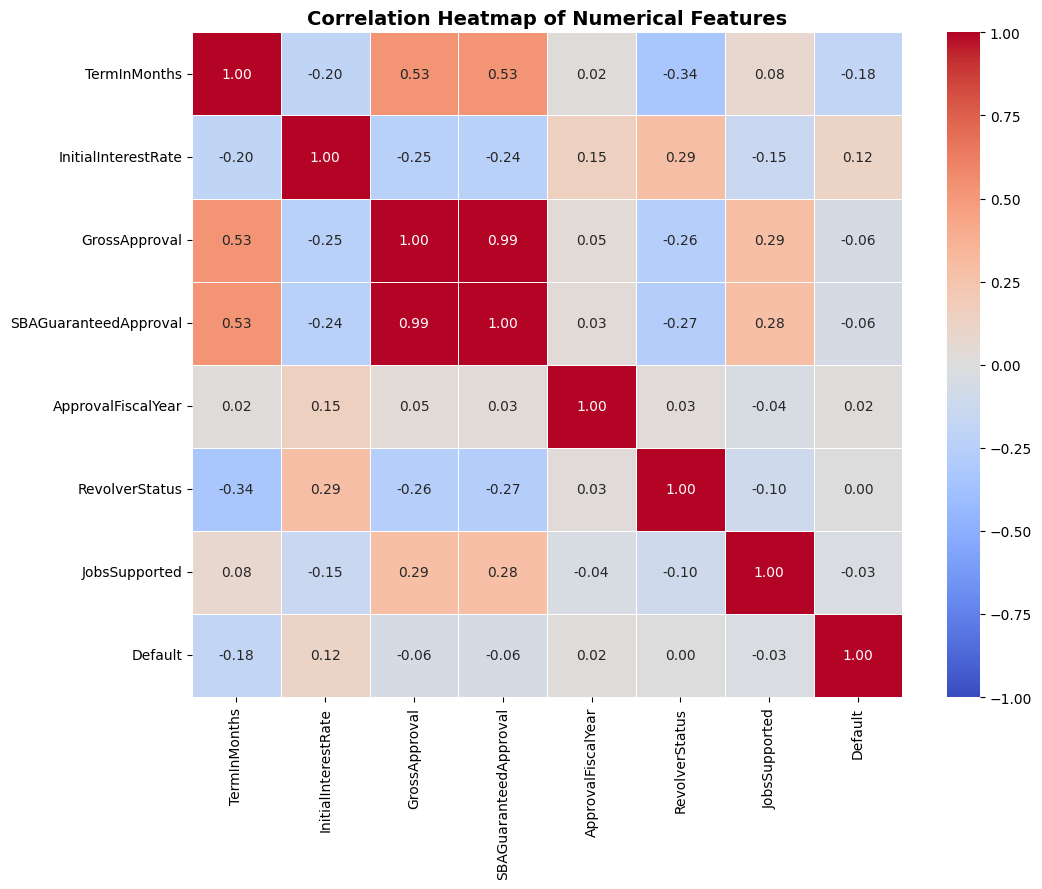

In [17]:
# STEP 16: CORRELATION HEATMAP OF NUMERICAL FEATURES

# Select numerical columns
numerical_cols = [
    'TermInMonths', 'InitialInterestRate', 'GrossApproval',
    'SBAGuaranteedApproval', 'ApprovalFiscalYear', 'RevolverStatus',
    'JobsSupported', 'Default'
]
df_numerical = df[numerical_cols]
df_numerical = df[numerical_cols]

# Calculate the correlation matrix
corr_matrix = df_numerical.corr()

# Create a heatmap
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    ax=ax
)
ax.set_title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')

# Print the correlation values with Default column
default_corr = corr_matrix['Default'].drop('Default')
default_corr_sorted = default_corr.abs().sort_values(ascending=False)

# Re-map the actual signed correlation values back to the sorted index for accuracy
final_corr_output = corr_matrix.loc[default_corr_sorted.index, 'Default']


print("CORRELATION WITH DEFAULT STATUS:")
print(final_corr_output.map(lambda x: f"{x:,.4f}").to_string())


## Dropping SBAGuaranteedApproval

`SBAGuaranteedApproval` had a 0.99 correlation with `GrossApproval` meaning they carry almost identical information. Keeping both would introduce **multicollinearity**, where the model gets confused by two features saying the same thing.`GrossApproval` will be kept since it represents the total loan size, which is the more important business
metric.

In [18]:
# STEP 17: REMOVE MULTICOLLINEAR FEATURES & FINAL DATA STATE CHECK

# Drop SBAGuaranteedApproval
df = df.drop(columns=['SBAGuaranteedApproval'])

# Print the final column list
print("Final Columns Post-Cleaning:")
print(df.columns.tolist())


# Print the final shape of the dataset
print(f"Final Dataframe Shape: {df.shape}")

Final Columns Post-Cleaning:
['AsOfDate', 'Program', 'BorrName', 'BorrStreet', 'BorrCity', 'BorrState', 'BorrZip', 'BankName', 'BankFDICNumber', 'BankNCUANumber', 'BankStreet', 'BankCity', 'BankState', 'BankZip', 'GrossApproval', 'ApprovalDate', 'ApprovalFiscalYear', 'FirstDisbursementDate', 'DeliveryMethod', 'subpgmdesc', 'InitialInterestRate', 'TermInMonths', 'NaicsCode', 'NaicsDescription', 'FranchiseCode', 'FranchiseName', 'ProjectCounty', 'ProjectState', 'SBADistrictOffice', 'CongressionalDistrict', 'BusinessType', 'BusinessAge', 'LoanStatus', 'PaidInFullDate', 'ChargeOffDate', 'GrossChargeOffAmount', 'RevolverStatus', 'JobsSupported', 'Default']
Final Dataframe Shape: (347135, 39)


## Feature Preparation

13 of the 14 cleaned columns are used for modeling. `NaicsDescription` is
dropped in favor of `NaicsCode`, since the two columns represent the same
industry classification in different formats.

Features are split into two groups based on how the model should treat them:

- **Numerical:** `GrossApproval`, `ApprovalFiscalYear`, `InitialInterestRate`,
  `TermInMonths`, `RevolverStatus`, `JobsSupported` : qantities.
- **Categorical:** `BorrState`, `ProjectState`, `DeliveryMethod`, `subpgmdesc`,
  `BusinessType`, `NaicsCode`:  these are labels, not quantities

`NaicsCode` is stored as a number in the raw data (e.g. `332812.0`) but is
really a category label, so it's cast to string before encoding.

In [19]:
# STEP 18: FEATURE PREPARATION
# Drop NaicsDescription
df = df.drop(columns=['NaicsDescription'])
df['NaicsCode'] = df['NaicsCode'].astype(int).astype(str).str[:2]   # <-- combined here, truncated to 2-digit sector

categorical_cols = ['BorrState', 'DeliveryMethod', 'subpgmdesc',
                     'ProjectState', 'BusinessType', 'NaicsCode']
numerical_cols = ['GrossApproval', 'ApprovalFiscalYear', 'InitialInterestRate',
                   'TermInMonths', 'RevolverStatus', 'JobsSupported']

X = df[categorical_cols + numerical_cols]
y = df['Default']

print(f"Feature matrix shape: {X.shape}")
print(f"Categorical features: {categorical_cols}")
print(f"Numerical features: {numerical_cols}")

Feature matrix shape: (347135, 12)
Categorical features: ['BorrState', 'DeliveryMethod', 'subpgmdesc', 'ProjectState', 'BusinessType', 'NaicsCode']
Numerical features: ['GrossApproval', 'ApprovalFiscalYear', 'InitialInterestRate', 'TermInMonths', 'RevolverStatus', 'JobsSupported']


In [20]:
print(df['NaicsCode'].nunique())
print(df['BorrState'].nunique())

24
57


## Train-Test Split

The data is split 80/20 into training and test sets, stratified on `Default`
so both sets preserve the same 8.04% default rate. Without stratification,
random sampling on an imbalanced target could produce a test set with a
meaningfully different default rate than training, skewing evaluation.

In [21]:
# STEP 19: TRAIN-TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"\nTrain default rate: {y_train.mean()*100:.2f}%")
print(f"Test default rate: {y_test.mean()*100:.2f}%")

Training set shape: (277708, 12)
Test set shape: (69427, 12)

Train default rate: 8.04%
Test default rate: 8.04%


## Preprocessing Pipeline

Numerical features are standardized since Logistic Regression is sensitive to feature scale. Without this, a feature like `GrossApproval` (range:
thousands to millions) would dominate the model over something like `InitialInterestRate`, regardless of actual predictive value.

Categorical features are one-hot encoded, with `handle_unknown='ignore'`
so the pipeline doesn't break if the test set contains a category that wasn't seen during training.

The preprocessor is only applied on `X_train`, inside each model's pipeline,
never on the full dataset so no information from the test set leaks
into preprocessing.

In [22]:
# STEP 20: PREPROCESSING PIPELINE
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

## Evaluation Framework

A shared helper function evaluates every model consistently on the same
3 metrics:

- **F1 Score**: balances catching actual defaults against false alarms.
 Accuracy isn't used here because it's misleading on imbalanced data: a model that never predicts default would still score 92% accuracy while catching zero defaults.
- **PR-AUC**: measures how well the model ranks risk across all possible thresholds, not just one cutoff.
- **Confusion Matrix**: shows the two types of mistakes lenders actually
  care about: missed defaults vs. good loans wrongly
  flagged as risky.

- `results` stores each model's scores so all three models can be compared
side-by-side once training is complete.
- A full classification report (precision/recall per class) is also
printed for additional detail on each individual model.





In [23]:
# STEP 21: EVALUATION HELPER FUNCTION
from sklearn.metrics import (f1_score, average_precision_score,
                              confusion_matrix, classification_report)

results = {}

def evaluate_model(name, y_true, y_pred, y_proba):
    f1 = f1_score(y_true, y_pred)
    pr_auc = average_precision_score(y_true, y_proba)
    cm = confusion_matrix(y_true, y_pred)

    results[name] = {'F1': f1, 'PR-AUC': pr_auc, 'Confusion Matrix': cm}

    print(f"=== {name} ===")
    print(f"F1 Score: {f1:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['PIF (0)', 'Default (1)'], zero_division=0))

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
                xticklabels=['PIF', 'Default'], yticklabels=['PIF', 'Default'])
    plt.title(f'{name} — Confusion Matrix', fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return f1, pr_auc, cm

## Model 1: Naive Baseline

Predicts "no default" (0) for every single loan. This is the floor every
real model must beat. On the surface it looks strong with 92% accuracy,
since 92% of loans really are paid in full, but it's completely useless
for the actual business problem: it never flags a single default.

F1 Score is 0 and PR-AUC lands at ~0.08, equal to the
dataset's overall default rate.

=== Naive Baseline ===
F1 Score: 0.0000
PR-AUC: 0.0804

Confusion Matrix:
[[63844     0]
 [ 5583     0]]

Classification Report:
              precision    recall  f1-score   support

     PIF (0)       0.92      1.00      0.96     63844
 Default (1)       0.00      0.00      0.00      5583

    accuracy                           0.92     69427
   macro avg       0.46      0.50      0.48     69427
weighted avg       0.85      0.92      0.88     69427



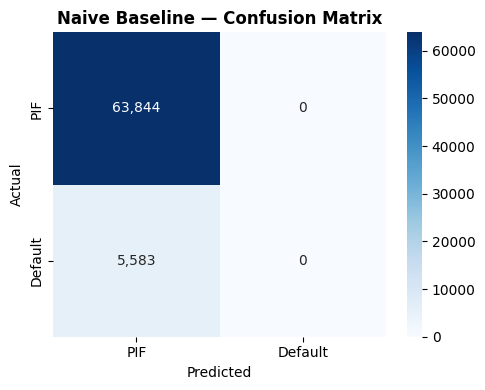

(0.0,
 np.float64(0.08041540034856756),
 array([[63844,     0],
        [ 5583,     0]]))

In [24]:
# STEP 22: MODEL 1 NAIVE BASELINE
y_pred_naive = np.zeros(len(y_test), dtype=int)
y_proba_naive = np.zeros(len(y_test))

evaluate_model('Naive Baseline', y_test, y_pred_naive, y_proba_naive)

## Model 2: Logistic Regression

Trained with `class_weight='balanced'`, which reweights the loss function so the rare default class isn't drowned out by the majority class during training.

Result: F1 jumps from 0.0000 to 0.3438, and PR-AUC from 0.0804 to 0.3716. The model catches 4,559 of 5,583 actual defaults, but at the cost of 16,383 false positives, flagging many good loans as risky. This precision/recall tradeoff is expected from `class_weight= 'balanced'`: it's tuned to catch defaults, not to be precise about it.


=== Logistic Regression ===
F1 Score: 0.3438
PR-AUC: 0.3716

Confusion Matrix:
[[47461 16383]
 [ 1024  4559]]

Classification Report:
              precision    recall  f1-score   support

     PIF (0)       0.98      0.74      0.85     63844
 Default (1)       0.22      0.82      0.34      5583

    accuracy                           0.75     69427
   macro avg       0.60      0.78      0.59     69427
weighted avg       0.92      0.75      0.80     69427



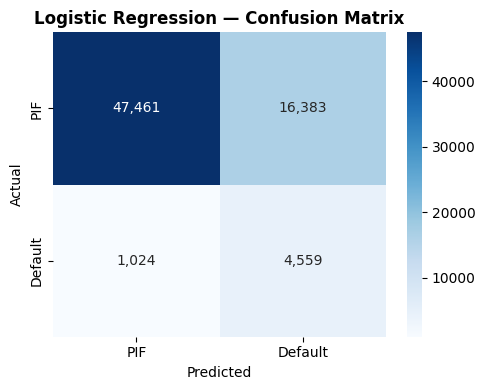

In [25]:
# STEP 23: MODEL 2 LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced',
                                       max_iter=1000, random_state=42))
])

logreg_pipeline.fit(X_train, y_train)

y_pred_lr = logreg_pipeline.predict(X_test)
y_proba_lr = logreg_pipeline.predict_proba(X_test)[:, 1]

evaluate_model('Logistic Regression', y_test, y_pred_lr, y_proba_lr);

## Hyperparameter Tuning for Random Forest

A Random Forest model has several hyperparameters that control how it's built. These settings aren't learned from the data the way the model's actual predictions are; they have to be chosen beforehand, and the right choice can meaningfully change how well the model performs.

This steps earches over a range of possible settings and keeps whichever
combination performs best, measured using 3-fold cross-validation on the training data. This is done with `RandomizedSearchCV`, which tries a random sample of combinations rather than every possible one.

The search is scored using PR-AUC, the same metric used to evaluate all
of the models in this notebook, so the "best" settings found here are
best specifically for the metric this project cares about,


In [30]:

# STEP 24: HYPERPARAMETER SEARCH FOR RANDOM FOREST
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_search_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1))
])

param_distributions = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 15, 20],
    'classifier__min_samples_leaf': [5, 10, 20],
    'classifier__min_samples_split': [10, 20],
    'classifier__max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=rf_search_pipeline,
    param_distributions=param_distributions,
    n_iter=4,
    scoring='average_precision',
    cv=2,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

print(f"Best cross-validated PR-AUC: {random_search.best_score_:.4f}")
print("\nBest hyperparameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best cross-validated PR-AUC: 0.5711

Best hyperparameters found:
  classifier__n_estimators: 100
  classifier__min_samples_split: 20
  classifier__min_samples_leaf: 5
  classifier__max_features: log2
  classifier__max_depth: 20


## Model 3: Random Forest (Final Optimized Model)


This model uses the hyperparameters found by the `RandomizedSearchCV` in the previous step, instead of hand-picked values. Like Logistic Regression, `class_weight='balanced'`is used to handle the 92/8 class imbalance. The search selected this combination based on a cross-validated PR-AUC of 0.5711.

On the test set, Random Forest scores F1 = 0.5012 and PR-AUC = 0.5672,
both a clear improvement over Logistic Regression . It also catches more actual defaults versus Logistic Regression's while cutting false positives
roughly in half. This means Random Forest correctly flags more real defaults while wrongly flagging far fewer good loans as risky, which is the better outcome for a lending model.

=== Random Forest ===
F1 Score: 0.5012
PR-AUC: 0.5672

Confusion Matrix:
[[55116  8728]
 [  797  4786]]

Classification Report:
              precision    recall  f1-score   support

     PIF (0)       0.99      0.86      0.92     63844
 Default (1)       0.35      0.86      0.50      5583

    accuracy                           0.86     69427
   macro avg       0.67      0.86      0.71     69427
weighted avg       0.93      0.86      0.89     69427



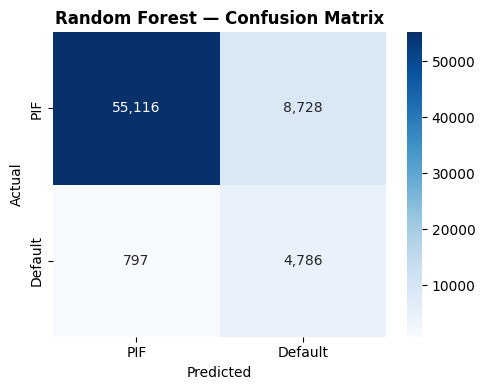

In [31]:
# STEP 25: MODEL 3 - RANDOM FOREST (FINAL OPTIMIZED MODEL)

rf_pipeline = random_search.best_estimator_

y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

evaluate_model('Random Forest', y_test, y_pred_rf, y_proba_rf);

## Model Comparison

The precision-recall curves make the difference between the two models visible across every possible decision threshold, not just the default one. Random Forest's curve sits above Logistic Regression's for almost the entire range, meaning it achieves higher precision at any given recall level, and vice versa.

Random Forest is the clear winner on both metrics, and is the model
selected for this project. It beats Logistic Regression by a wide
margin on F1 and PR-AUC, meaning it not only performs better at one specific cutoff, but ranks risk more accurately across the board.

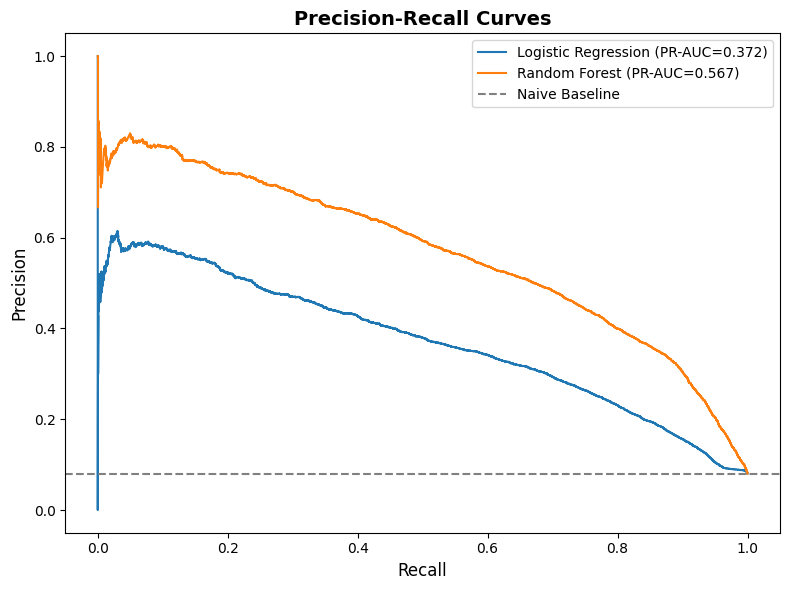

MODEL COMPARISON SUMMARY:
              Model  F1 Score   PR-AUC
     Naive Baseline  0.000000 0.080415
Logistic Regression  0.343751 0.371624
      Random Forest  0.501231 0.567248


In [32]:
# STEP 26: MODEL COMPARISON

# Precision-Recall curves overlay
from sklearn.metrics import precision_recall_curve
plt.figure(figsize=(8, 6))
for name, y_proba in [('Logistic Regression', y_proba_lr),
                       ('Random Forest', y_proba_rf)]:
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(recall, precision, label=f'{name} (PR-AUC={results[name]["PR-AUC"]:.3f})')

plt.axhline(y=y_test.mean(), color='gray', linestyle='--', label='Naive Baseline')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Summary table
summary_df = pd.DataFrame({
    'Model': list(results.keys()),
    'F1 Score': [results[m]['F1'] for m in results],
    'PR-AUC': [results[m]['PR-AUC'] for m in results]
})
print("MODEL COMPARISON SUMMARY:")
print(summary_df.to_string(index=False))